In [1]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

2026-06-16 11:20:39.376210: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-16 11:20:39.806798: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-16 11:20:43.317445: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from plot_data import *
from process_data import *


sys.path.insert(0, "/lustre/lrspec/users/4301/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw 
from logwave import log_rebin


from snid_sage.snid import preprocessing as snid_pp 



In [4]:
def folder_to_dataframe(folder, 
                        folder_loc = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/",
                        save_dir = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/folder_parquet",
                        num_wvl = 23411,
                        save = True,
                        indicies = (None,None) ):
    
    filenames = sorted(glob.glob(folder_loc+ folder +"/*"))[indicies[0]: indicies[1]]
    file_info = [name.split("/")[-1] for name in filenames]
    df_metadata = pd.DataFrame(file_info, columns=["filename"])
    df_metadata[["host", "sn_type", "redshift", "SN_mag", "host_mag"]] = [get_filename_info(info) for info in file_info]
    df_metadata[ "host_mag"] = df_metadata[ "host_mag"].astype(float)
    df_metadata[ "redshift"] = df_metadata[ "redshift"].astype(float)
    df_metadata[ "SN_mag"] = df_metadata[ "SN_mag"].astype(float)

    # set up to extract the X values 
    num_wvl = 23411
    dat_size = len(df_metadata)
    plots = False
    
    X_all = np.zeros((dat_size, num_wvl))
    ABC_IDs = np.zeros((dat_size)) # classification as the float classifier
    Mill_IDs = np.zeros((dat_size)) # classification as the float classifier

    # extract flux and wavelength values from each file 
    for i, filename in enumerate(filenames):
        sep = " " # Define separator for reading data
        s = pd.read_csv(filename, sep=sep, header=None, comment="#") # Read the spectrum data
        wave = s[0]
        X_all[i] = s[1]

        # getting data 
        ABC_type, Mill_type = get_ABC_Mill_type(df_metadata["sn_type"].iloc[i])
        ABC_IDs[i] = ABC_type
        Mill_IDs[i] = Mill_type
        

    # combining metadata and spectra data into single df
    df_metadata["ABC_type"] = ABC_IDs
    df_metadata["Mill_type"] = Mill_IDs    
    df_metadata["Spectral Phase"] = np.zeros((dat_size))
    df_spec = pd.DataFrame(X_all, columns = wave)
    df_folder = pd.concat([df_metadata, df_spec], axis=1)
    df_folder = df_folder.drop(["filename"], axis = 1)

    if save:
        df_folder.to_parquet(os.path.join(save_dir, folder + ".parquet"))

    return df_folder
    

In [5]:
from scipy.interpolate import interp1d

def interp_flux_logspace(log_wave, wvl0, fluxes0):
    # fluxes0 shape: (N_spectra, N_wavelengths)
    f = interp1d(wvl0, fluxes0, axis=1, bounds_error=False, fill_value=0.0)
    return f(log_wave)

def spectrum_logspace(wvl0, fluxes0, w0, w1):
    # need to change cadence and range of data points 
    R_current = np.mean(wvl0[:-1] / np.diff(wvl0)) # current resolution
    nw = dg.calc_num_wvl_bins(R_current, (2500, 10_000)) # number of wavelengths
    w0, w1 = 2_500, 10_000 # wavelength range
    log_wave, wvl0_bin_sizes = dg.calc_new_wvl(R_current, wvl0, (w0, w1)) 
    flux = interp_flux_logspace(log_wave, wvl0, fluxes0) # from logwave  
    return log_wave, flux 
    

In [54]:
# based on snid enforce_positive_flux from ppreprocessing 
from numpy.typing import NDArray

def enforce_positive_flux(
    flux: NDArray[np.floating],
    *,
    eps_fraction: float = 1e-6,
) -> Tuple[NDArray[np.floating], float]:
    """
    based on snid_sage enforce_positive_flux from preprocessing with minor changes 
    
    Ensure that a flux array is strictly positive everywhere.

    This helper is designed for the SNID continuum fitter, which assumes
    non–negative real flux values when placing knots and taking log10
    averages.  It is intentionally unconditional: if *any* finite sample
    is ≤ 0, we shift the entire spectrum upward by a constant offset.

    Parameters
    ----------
    flux : array_like
        Input flux array (may contain negative/zero values and NaNs).
    eps_fraction : float, optional
        Small fractional safety margin relative to a robust flux scale
        (default 1e-6).  This avoids edge–case zeros after shifting.

    Returns
    -------
    shifted_flux : np.ndarray
        Flux array guaranteed to satisfy shifted_flux > 0 wherever the
        original data were finite.
    offset : float
        Constant added to the input flux (0.0 if no shift was required).
    """
    f = np.asarray(flux, dtype=float)
    if f.size == 0:
        return f.copy(), 0.0

    #find the start of the nonzero flux values
    flux_indices = np.where(~np.isclose(f, 0.0, atol=1e-16))[0]
    flux_start, flux_stop = valid_indices[0], valid_indices[-1]
    
    finite_mask = np.isfinite(f)
    if not np.any(finite_mask):
        return f.copy(), 0.0

    f_finite = f[finite_mask]

    # If fewer than 1% of finite samples are negative, treat this as a
    # normal fluxed spectrum and leave it unchanged. The continuum fitter
    # already ignores isolated negatives via its flux>0 masks.
    neg_frac = float(np.mean(f_finite < 0.0))
    if neg_frac < 0.01:
        return f.copy(), 0.0

    fmin = float(np.min(f_finite))
    if fmin > 0.0:
        # Already strictly positive; nothing to do.
        return f.copy(), 0.0

    # Robust scale for choosing a tiny positive epsilon.
    abs_vals = np.abs(f_finite)
    scale = float(np.median(abs_vals))
    if scale <= 0.0:
        # Fallback to max amplitude or 1.0 to avoid eps=0.
        scale = float(np.max(abs_vals)) if np.max(abs_vals) > 0.0 else 1.0

    # Guard against a *single* very deep negative outlier dominating fmin.
    # We clip the negative tail at -k * scale when determining the offset so that
    # continuum fitting still sees a strictly positive spectrum, but one or two
    # pathological pixels do not force an enormous upward shift that flattens all
    # real features (common in very long/high-resolution spectra).
    k = 1.2
    try:
        neg_clip_level = -k * scale
        f_finite_clipped = f_finite.copy()
        deep_neg_mask = f_finite_clipped < neg_clip_level
        if np.any(deep_neg_mask):
            _LOG.debug(
                "enforce_positive_flux: clipping %d deep negative sample(s) below %.3g "
                "to %.3g before computing offset",
                int(np.count_nonzero(deep_neg_mask)),
                float(f_finite_clipped[deep_neg_mask].min()),
                float(neg_clip_level),
            )
            f_finite_clipped[deep_neg_mask] = neg_clip_level
        fmin = float(np.min(f_finite_clipped))
    except Exception:
        # Fall back to the original minimum if clipping fails for any reason.
        fmin = float(np.min(f_finite))

    eps = float(eps_fraction) * scale
    if eps < 0.0:
        eps = 0.0

    offset = -fmin + eps

    # want to only shift nonzero data - ally
    shifted = f.copy()
    shifted[flux_start: flux_stop] += offset
    
    return shifted, float(offset)
    

def remove_continuum(flux, eps_fraction = 1e6):
    positive_flux, offset = enforce_positive_flux(flux, eps_fraction = 0.01)
    flattened_flux, cont = snid_pp.fit_continuum(positive_flux)
    return flattened_flux
remove_continuum_vec = np.vectorize(remove_continuum, signature='(n)->(n)')

In [55]:
test = [1,2,3,4,5,6,7]
test[None:None]

[1, 2, 3, 4, 5, 6, 7]

In [58]:
%%time
folder_list = ["kinney_sample1", "kinney_sample2", "kinney_sample3", "kinney_sample4", "kinney_sample5",
               "kinney_sample6", "kinney_sample7", "kinney_sample8", "kinney_sample9",
               "kinney_sample10", "kinney_sample11", "kinney_sample12", "kinney_sample13",
               "kinney_sample14"]
folder_list = ["kinney_sample14"]

plot_print = True
snidify = True
save = True 
save_dir = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/folder_parquet"
phase_range=(-20, 50)
ptp_range=(-np.inf, np.inf)
wvl_range=(4500, 7000)
file_indicies = (None, None) # processing all in the folder

def milligan_preprocessing(folder, # folder where spectra is located
                           file_indicies = (None, None), # processing all in the folder
                           plot_print = False, # plots the first flux at various stages 
                           snidify = True, # flattens spectra using a spline continuum 
                           save = True , # processed data is saved in a parquet 
                           save_dir = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/folder_parquet", # directory where data is saved
                           phase_range=(-20, 50), # removed spectra outside this rage
                           ptp_range=(-np.inf, np.inf),
                           wvl_range=(4500, 7000), # wavelength where flux is examined
                            ): 

    df_folder = folder_to_dataframe(folder, indicies = file_indicies, save = save)
    if plot_print:
        print("data loaded into dataframe")
    df_prep = preproccess_dataframe(df_folder, phase_range, ptp_range, wvl_range)
    if save:
        df_prep.to_parquet(os.path.join(save_dir, folder + "_preprocessed.parquet"))
    if plot_print:
        print("data preprocessed and saved")
        df_folder.loc[0].iloc[8:].T.plot()
        plt.title("orginal data preprocessed")
        plt.show()

    # extracting data
    R = 100
    data = dp.extract_dataframe(df_prep)
    index = data[0]  # SN Name for each spectrum
    wvl0 = data[1]  # Wavelength array
    flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
    df_metadata = data[5]  # Sub-dataframe containing only the metadata
    fluxes0 = data[6]  # Only the flux values in a numpy array

    # rebinning the spectra to be in a logspace 
    w0, w1 = 2_500, 10_000 # wavelength range
    log_wave, flux =  spectrum_logspace(wvl0, fluxes0, w0, w1)

    if plot_print:
        print("Data put into logspace")
        plt.plot(log_wave, flux[0], label = "logspace data")
        plt.plot(wvl0, fluxes0[0], alpha =0.5, label = "preprocessed data")
        plt.legend()
        plt.show()

    # normalize spectra using snid 
    if snidify:
        # normalize the spectra 
        flux = remove_continuum_vec(flux)

        if plot_print:
            plt.plot(log_wave, flux[0], label = "flattened data")
            plt.legend()
            plt.show()
            
    
    ## code from data_degrade.degrade_dataframe

    # Perform degradation (i.e. lowers resolution) for each spectrum in the dataset. The function
    # # degraded_spectrum is vectorized, so supplying multiple spectrum allows
    # # the operation to be parallelized.
    fluxes_convolve, wvl_degraded, fluxes_degraded = dg.degrade_spectrum(R, log_wave, flux)
    
    # `wvl_degraded` is actually multiple copies of the same wavelength array, 
    # so we only need the first one.
    degraded_flux_columns = wvl_degraded[0].astype(str)
    
    # Store the convolution data (not the rebinned spectra)
    sn_data_convolve = df_prep.copy(deep=True)
    sn_data_convolve = sn_data_convolve
    sn_data_convolve.loc[:, log_wave] = fluxes_convolve
    
    # Store the rebinned spectra into its own dataframe.
    df_fluxes_degraded = pd.DataFrame(data=fluxes_degraded,
                                      columns=degraded_flux_columns,
                                      index=index,
                                      dtype=float)
    sn_data_degraded = pd.concat([df_metadata, df_fluxes_degraded], axis=1)
    if save:
        sn_data_convolve.to_parquet(os.path.join(save_dir, folder + "_convoloved.parquet"))
        sn_data_degraded.to_parquet(os.path.join(save_dir, folder + "_rebinned.parquet"))
    
    if plot_print:
        print("data has been degraded to R = 100")
        #shifted data to new wavelength axis but not degraded 
        plt.plot(log_wave, fluxes_convolve[0], label = "convolved fluxed")
        plt.plot(wvl_degraded[0], fluxes_degraded[0], label = "degraded fluxed")
        
    return sn_data_degraded
        

CPU times: user 43 μs, sys: 0 ns, total: 43 μs
Wall time: 46 μs


In [ ]:
%%time
milligan_preprocessing("kinney_sample14", # folder where spectra is located
                           file_indicies = (0, 10), 
                           plot_print = True)

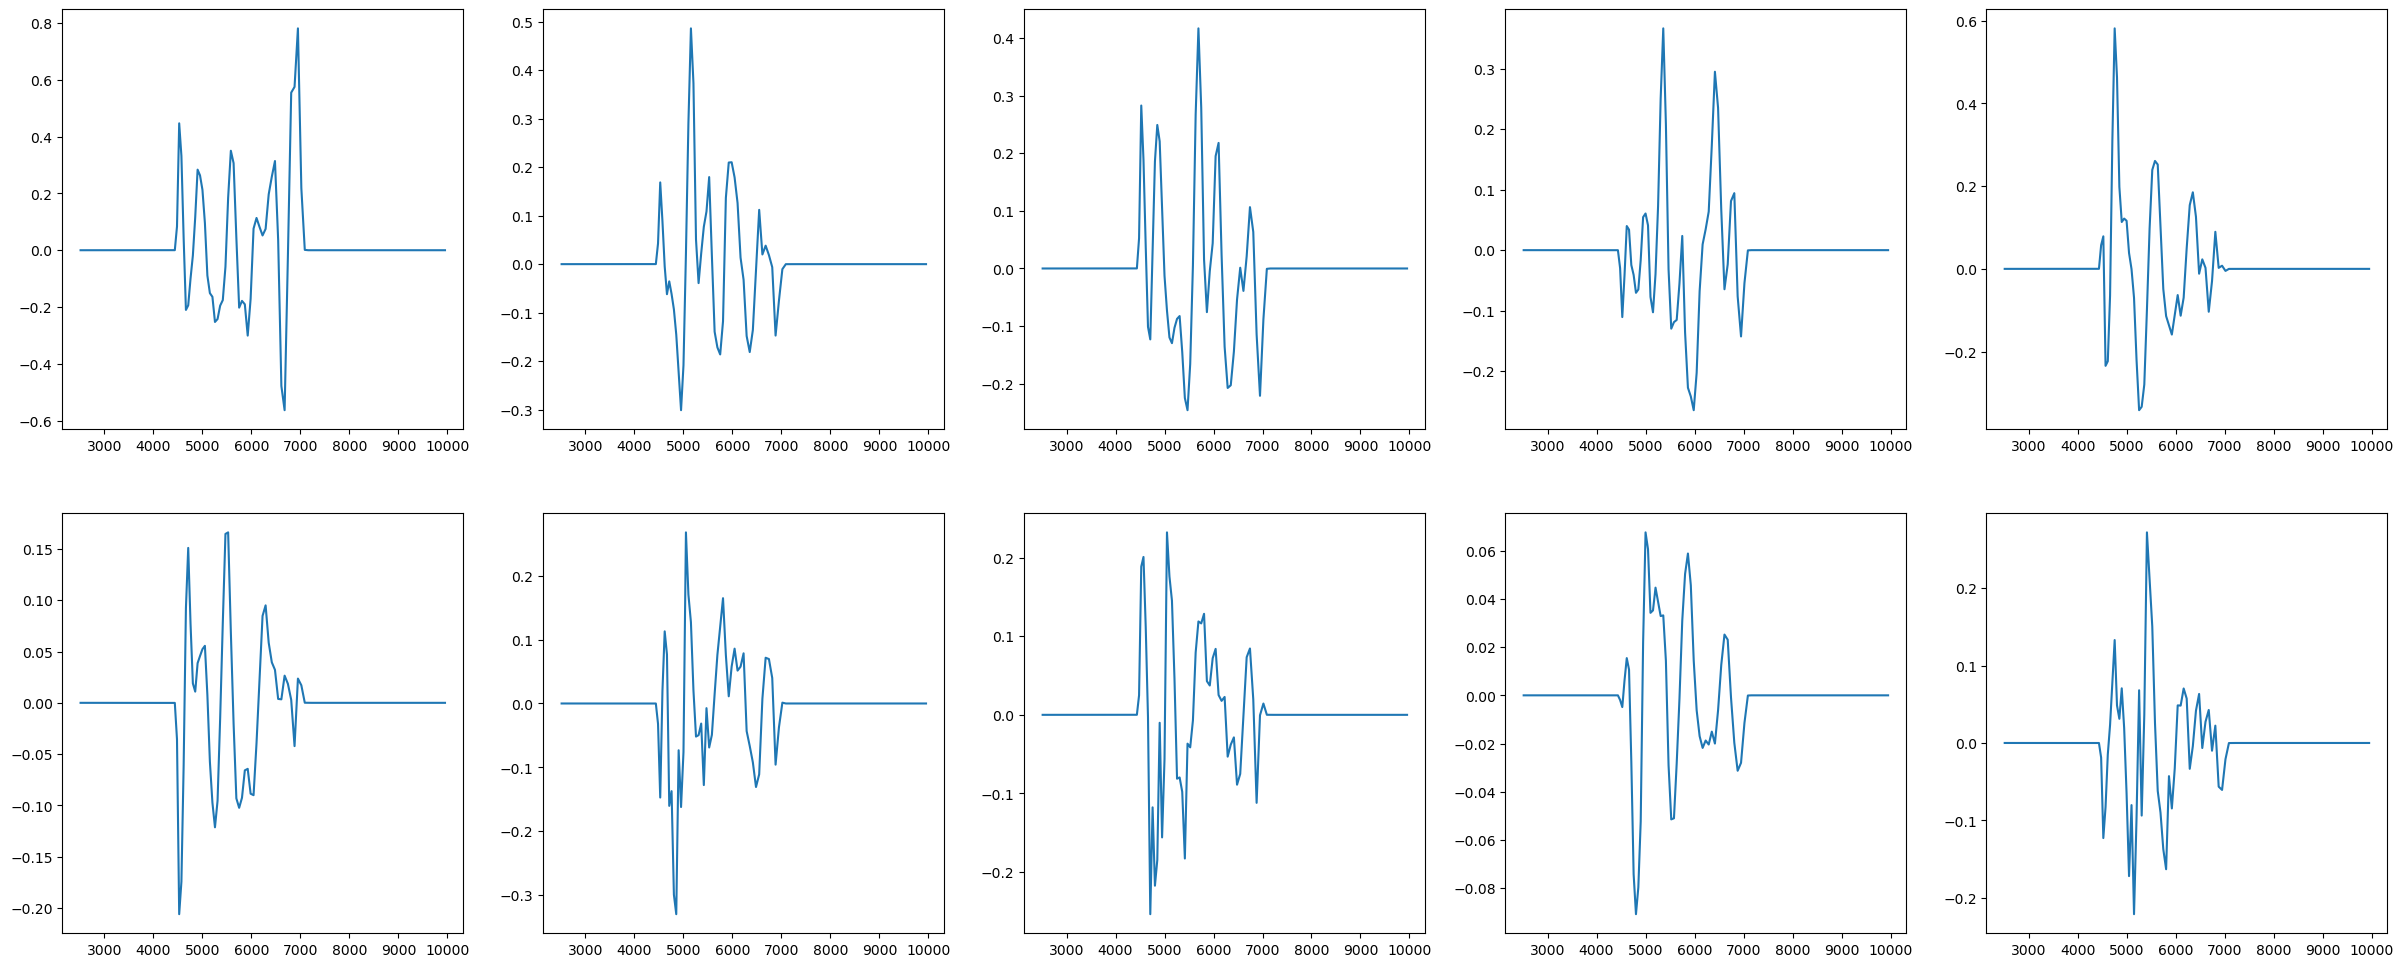

In [53]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30, 12))
# Flatten the 2D array of axes to easily iterate through all 10 plots sequentially
axes = axes.flatten()
for i in range(10):
    axes[i].plot(wvl_degraded[0], fluxes_degraded[i])

can remove individually stays closer to zero or all at once but it will affect the offset

In [31]:
valid_indices = np.nonzero(flux[0])[0]
valid_start, valid_stop = valid_indices[0], valid_indices[-1]

In [32]:
flux

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [42]:
%%time
flattened_flux= remove_continuum(flux[0])

CPU times: user 428 ms, sys: 834 μs, total: 429 ms
Wall time: 430 ms


In [45]:
%%time
flat = remove_continuum_vec(flux)

CPU times: user 4.32 s, sys: 285 ms, total: 4.61 s
Wall time: 4.37 s


In [16]:
%%time
positive_flux, offset, (flux_start, flux_stop)= enforce_positive_flux(flux[0], eps_fraction = 0.01)
flat_sage, cont_sage = snid_pp.fit_continuum(positive_flux)


CPU times: user 452 ms, sys: 784 μs, total: 453 ms
Wall time: 454 ms


In [29]:
offset

2.3725778653460288

In [178]:
sn_data_degraded

,ABC_type,Mill_type,SN_mag,Spectral Phase,host,host_mag,redshift,sn_type,2512.529050300541,2537.7127325827696,...,9096.145837554206,9187.318692546025,9279.405394966827,9372.415104528947,9466.357072754703,9561.240643896645,9657.075255867012,9753.870441176497,9851.635827882466,9950.38114054659
0,0.0,0.0,19.012,0.0,elliptical,21.234,0.088028,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,20.064,0.0,elliptical,19.533,0.122000,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,20.283,0.0,elliptical,23.627,0.236060,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,20.390,0.0,elliptical,20.883,0.163130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,20.914,0.0,elliptical,22.518,0.223470,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,21.391,0.0,elliptical,23.472,0.201570,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,21.407,0.0,elliptical,19.000,0.258950,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,21.420,0.0,elliptical,19.228,0.257790,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,21.511,0.0,elliptical,25.492,0.282350,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,21.601,0.0,elliptical,19.748,0.346380,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


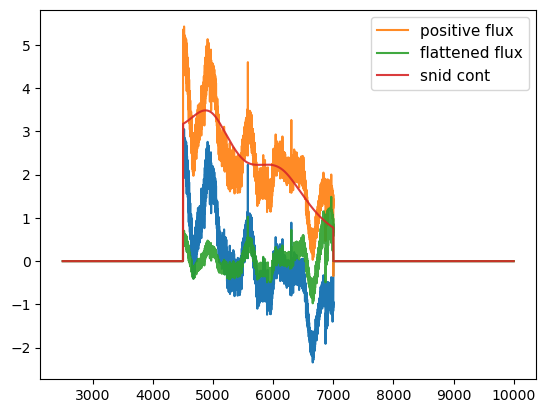

In [179]:
plt.plot(log_wave, flux[0])
plt.plot(log_wave, positive_flux, label= "positive flux", alpha = 0.9)
plt.plot(log_wave, flat_sage, label="flattened flux", alpha = 0.9)
plt.plot(log_wave, cont_sage, label="snid cont", alpha = 0.9)
plt.legend()

In [180]:
folder_loc = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/"

filenames = sorted(glob.glob(folder_loc+ "kinney_sample14" +"/*"))


In [181]:
sn_data_degraded

,ABC_type,Mill_type,SN_mag,Spectral Phase,host,host_mag,redshift,sn_type,2512.529050300541,2537.7127325827696,...,9096.145837554206,9187.318692546025,9279.405394966827,9372.415104528947,9466.357072754703,9561.240643896645,9657.075255867012,9753.870441176497,9851.635827882466,9950.38114054659
0,0.0,0.0,19.012,0.0,elliptical,21.234,0.088028,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,20.064,0.0,elliptical,19.533,0.122000,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,20.283,0.0,elliptical,23.627,0.236060,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,20.390,0.0,elliptical,20.883,0.163130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,20.914,0.0,elliptical,22.518,0.223470,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,21.391,0.0,elliptical,23.472,0.201570,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,21.407,0.0,elliptical,19.000,0.258950,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,21.420,0.0,elliptical,19.228,0.257790,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,21.511,0.0,elliptical,25.492,0.282350,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,21.601,0.0,elliptical,19.748,0.346380,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


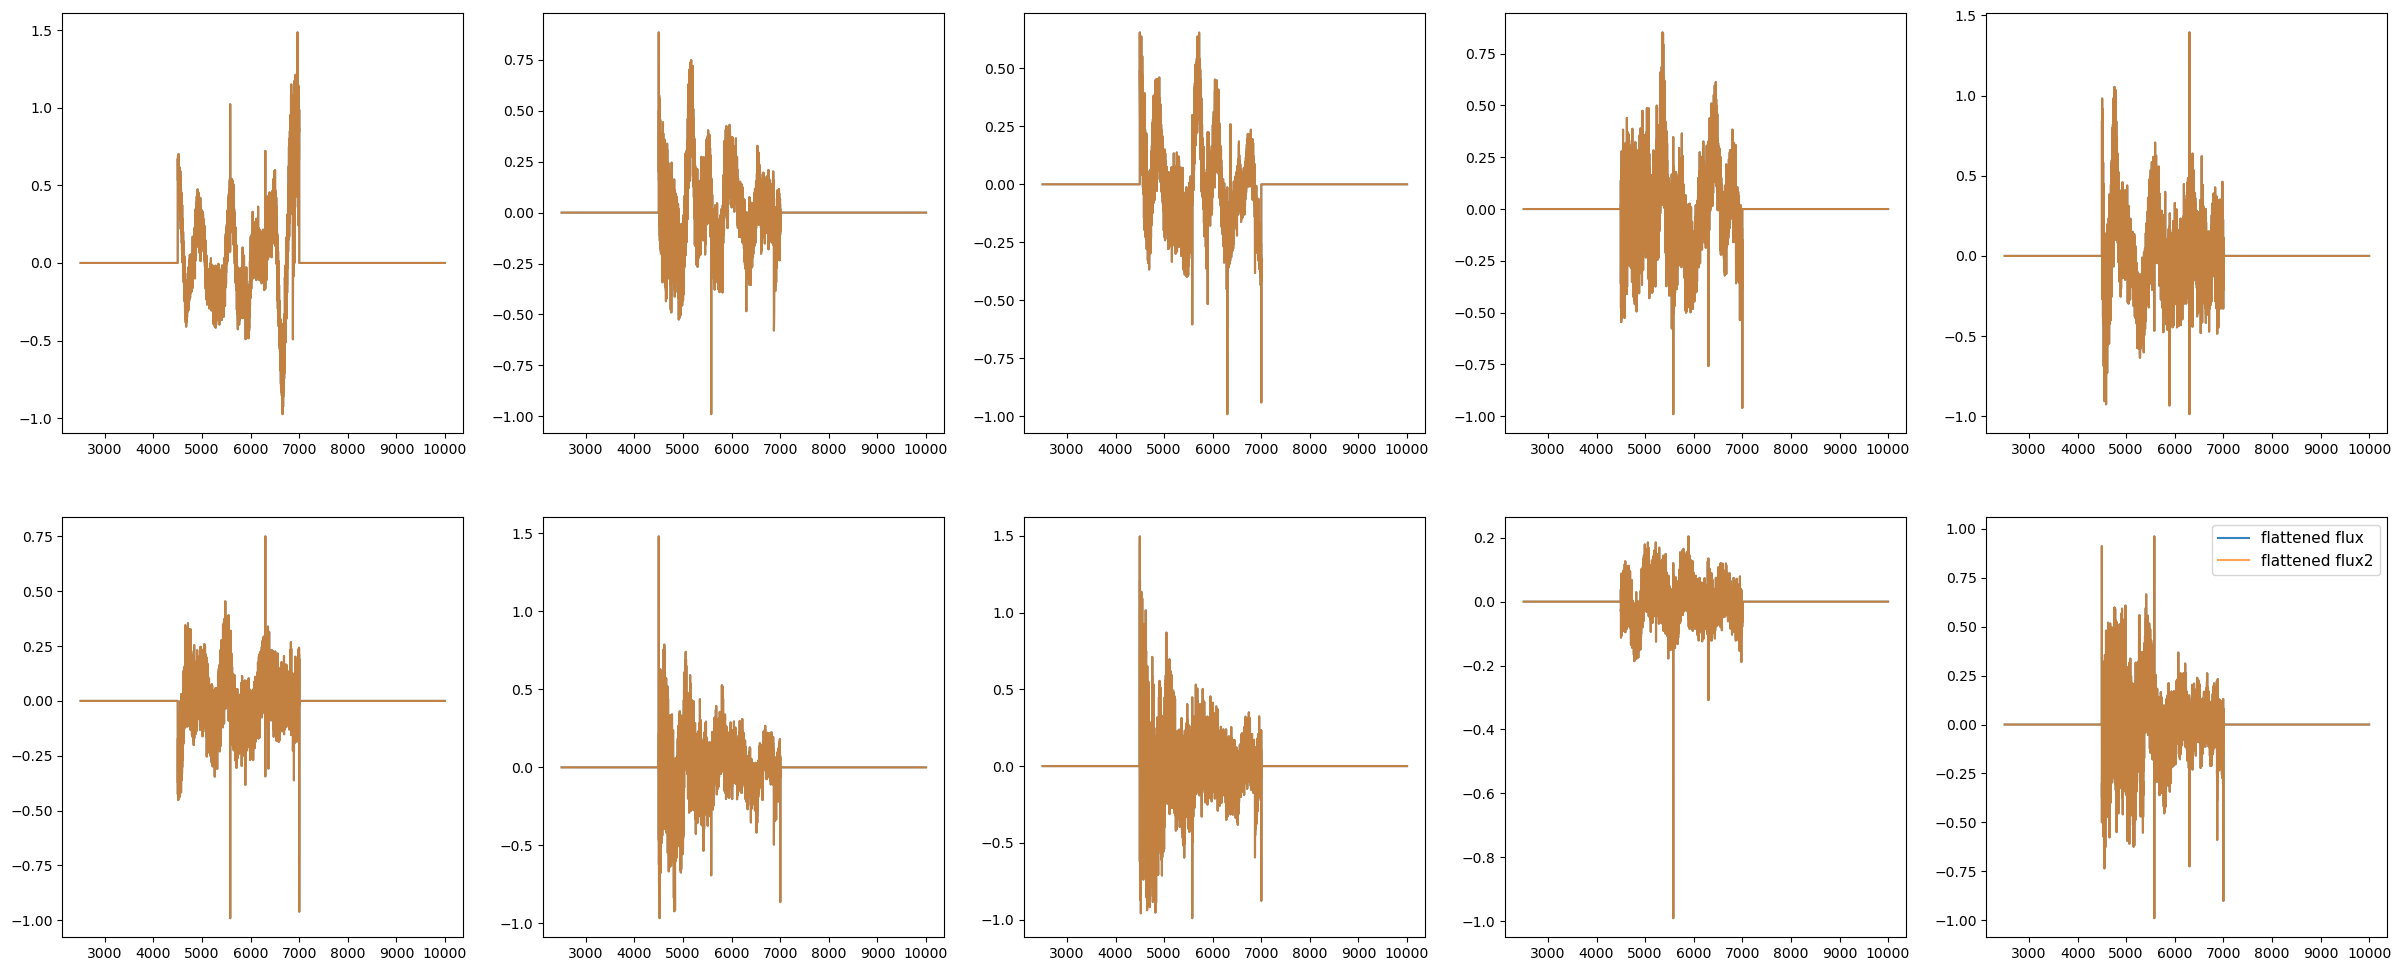

In [48]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30, 12))
# Flatten the 2D array of axes to easily iterate through all 10 plots sequentially
axes = axes.flatten()
for i in range(10):
    #axes[i].plot(log_wave, flux[i])
    positive_flux, offset = enforce_positive_flux(flux[i], eps_fraction = 0.01)
    flat_sage, cont_sage = snid_pp.fit_continuum(positive_flux)
    #axes[i].plot(log_wave, positive_flux, label= "positive flux", alpha = 0.9)
    axes[i].plot(log_wave, flat_sage, label="flattened flux", alpha = 0.9)
    #axes[i].plot(log_wave, cont_sage, label="snid cont", alpha = 0.9)
plt.legend()

why are the bounds weird

[np.int64(55), np.int64(106)]
[np.int64(55), np.int64(106)]
[np.int64(55), np.int64(106)]
[np.int64(55), np.int64(106)]
[np.int64(55), np.int64(106)]
[np.int64(55), np.int64(106)]
[np.int64(55), np.int64(106)]
[np.int64(55), np.int64(106)]
[np.int64(56), np.int64(106)]
[np.int64(55), np.int64(106)]


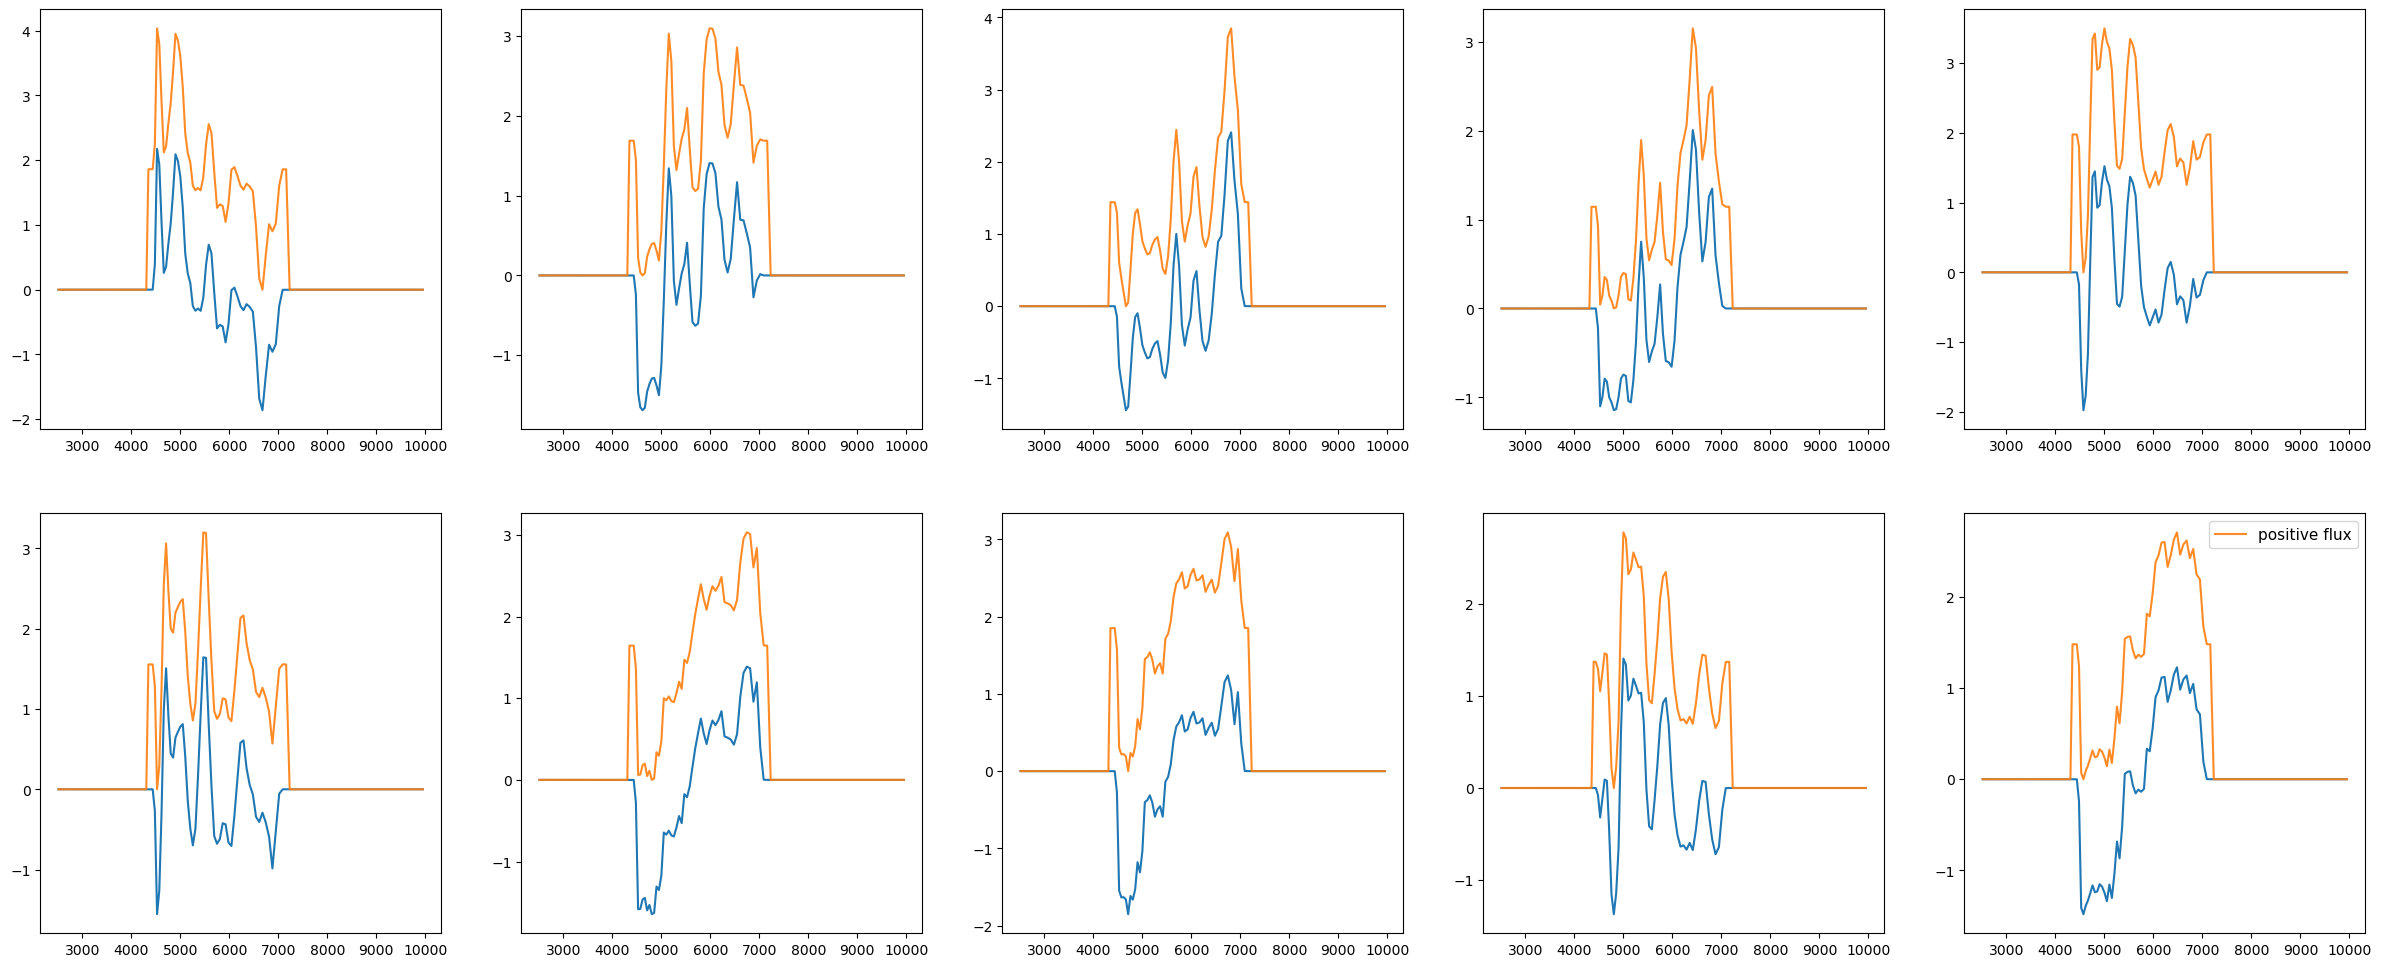

In [186]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30, 12))
# Flatten the 2D array of axes to easily iterate through all 10 plots sequentially
axes = axes.flatten()
for i in range(10):
    axes[i].plot(wvl_degraded[0], fluxes_degraded[i])
    positive_flux, offset = enforce_positive_flux(fluxes_degraded[i], eps_fraction = 0.01)
    flat_sage, cont_sage = snid_pp.fit_continuum(positive_flux)
    axes[i].plot(wvl_degraded[0], positive_flux, label= "positive flux", alpha = 0.9)
    # axes[i].plot(wvl_degraded[0], flat_sage, label="flattened flux", alpha = 0.9)
    # axes[i].plot(wvl_degraded[0], cont_sage, label="snid cont", alpha = 0.9)
plt.legend()